In [220]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


# Parallel optimization, tweezed vs untweezed with defined functions, not optimized power

In [222]:
P_opt = [50e-3]
w0 = 1e-6
f_rf_r = 3e6
f_rf_a= 0.125e6

results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []
# First 5: 1e6 and /3, last 2: 2e6 and /5

print(f_rf_r,f_rf_a)
for Ni in range(2,8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i-2][1][0][2] for i in range(2,8)]

3000000.0 125000.0


In [223]:
untweezed_winners

[0.03956930721333248,
 0.03230820404936483,
 0.027979725457404795,
 0.02502582724581768,
 0.02284535017126496,
 0.021150684374903053]

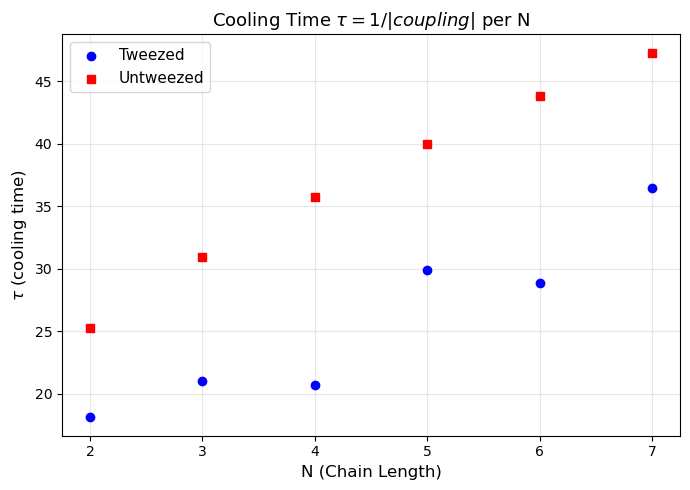

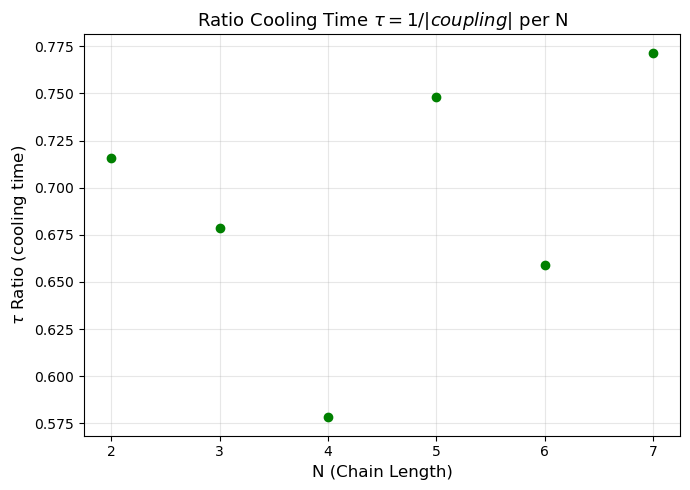

In [224]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores (same approach) ---
untweezed_data = {}  # {N: score}

for N_val, winners in untweezed_results:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data.keys())
scores_untweezed = [untweezed_data[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=12)
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ Ratio (cooling time)', fontsize=12)
ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Power sweep

In [231]:
N_values = np.arange(2,8)
w0 = 1e-6
P_list = np.linspace(1e-6,0.25,100)  # optical powers from 10 mW to 1 W
# --- Run power sweep using your tweezed-only function ---
power_results = [ [] for _ in N_values]  # List of lists to hold winners for each N
for N in N_values:
    for P in P_list:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            f_rf_a,
            P,
            w0,
            max_tweezed=1
        )
        power_results[N-2].append(winners)


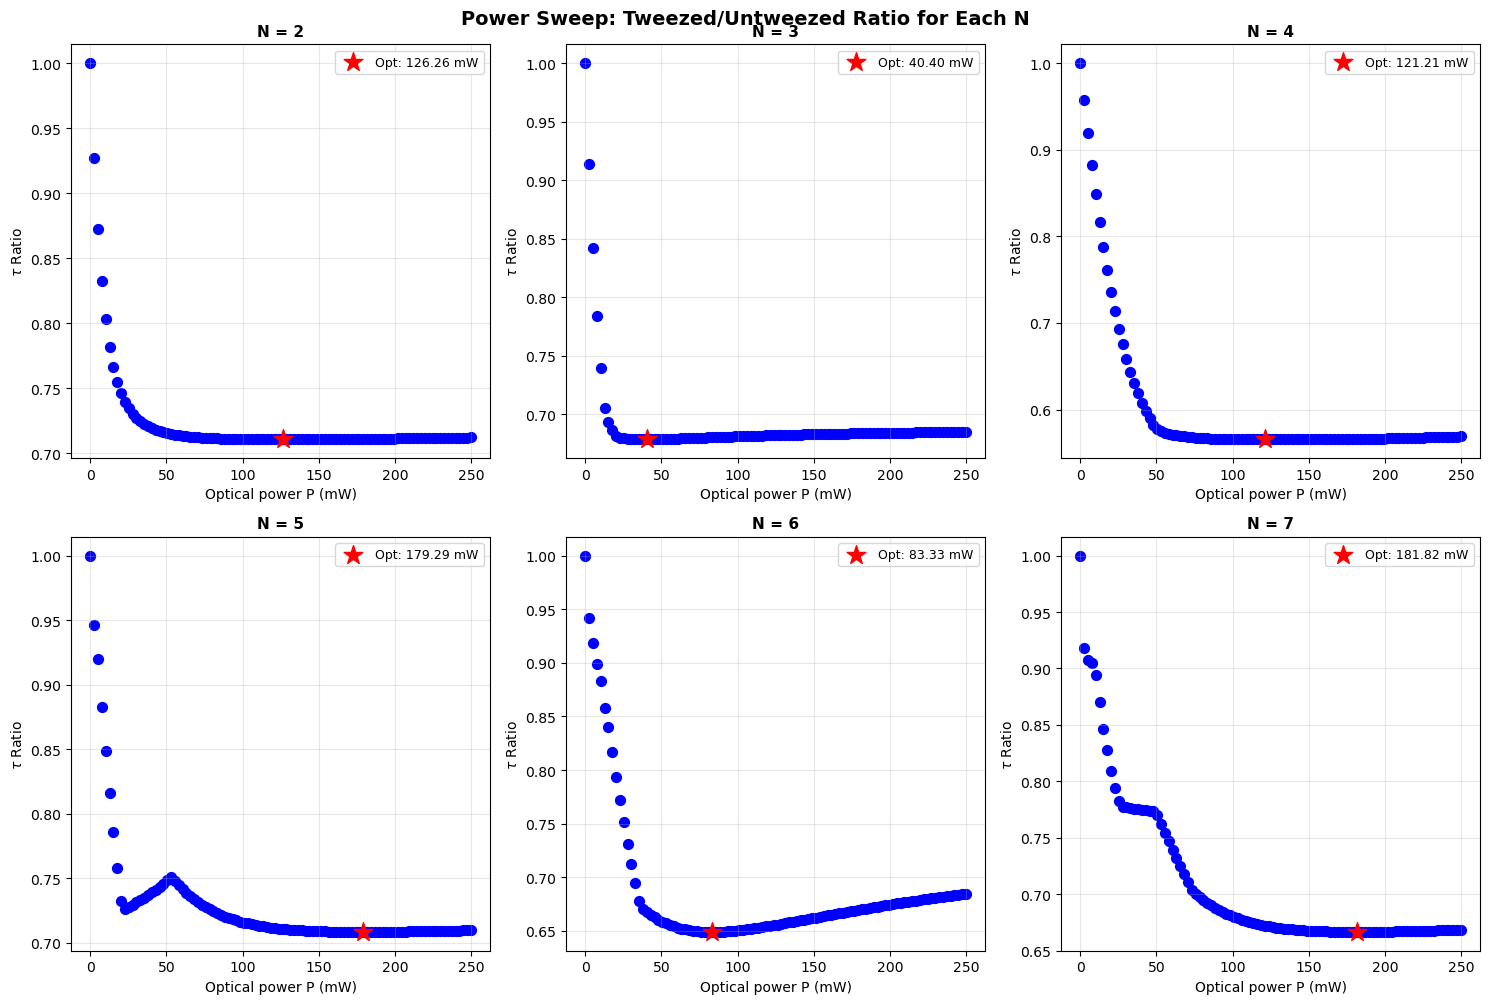


Optimal Powers Summary:
N = 2: P_opt = 1.262631e-01 W = 126.2631 mW,  Ratio = 0.7108
N = 3: P_opt = 4.040488e-02 W = 40.4049 mW,  Ratio = 0.6786
N = 4: P_opt = 1.212126e-01 W = 121.2126 mW,  Ratio = 0.5655
N = 5: P_opt = 1.792932e-01 W = 179.2932 mW,  Ratio = 0.7084
N = 6: P_opt = 8.333400e-02 W = 83.3340 mW,  Ratio = 0.6490
N = 7: P_opt = 1.818185e-01 W = 181.8185 mW,  Ratio = 0.6666


In [232]:
# --- Extract and plot for each N ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

optimal_powers_W = []
optimal_powers_mW = []
optimal_ratios = []

for Ni in range(2,8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i-2][1][0][2] for i in range(2,8)]

for idx, N in enumerate(N_values):
    x_tweezed = []
    y_tweezed = []
    
    # Extract scores from power_results for this N
    for P_opt, winners in zip(P_list, power_results[N-2]):
        if not winners:
            continue
        winner = winners[0]
        
        if len(winner) >= 3:
            tweezed_ion = winner[0]
            score = winner[2]
        else:
            continue
        
        if tweezed_ion is None:
            continue
        
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(score))
    
    x_tweezed = np.array(x_tweezed)
    y_tweezed = np.array(y_tweezed)
    
    untweezed_ref = untweezed_winners[N-2]
    
    if len(y_tweezed) > 0:
        ratio = untweezed_ref / y_tweezed
        opt_idx = np.argmin(ratio)
        
        opt_power_W = x_tweezed[opt_idx]
        opt_power_mW = opt_power_W * 1e3
        opt_ratio = ratio[opt_idx]
        
        optimal_powers_W.append(opt_power_W)
        optimal_powers_mW.append(opt_power_mW)
        optimal_ratios.append(opt_ratio)
        
        # Plot
        axes[idx].scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
        axes[idx].set_xlabel("Optical power P (mW)", fontsize=10)
        axes[idx].set_ylabel(r"$\tau$ Ratio", fontsize=10)
        axes[idx].set_title(f"N = {N}", fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        axes[idx].scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
                         zorder=5, label=f'Opt: {opt_power_mW:.2f} mW')
        axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Power Sweep: Tweezed/Untweezed Ratio for Each N", 
             fontsize=14, fontweight='bold', y=1.00)
plt.show()

# --- Print summary (AFTER loop completes) ---
optimal_powers_W = np.array(optimal_powers_W)
optimal_powers_mW = np.array(optimal_powers_mW)
optimal_ratios = np.array(optimal_ratios)

print("\nOptimal Powers Summary:")
print("=" * 60)
for N, P_W, P_mW, ratio in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios):
    print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
print("=" * 60)

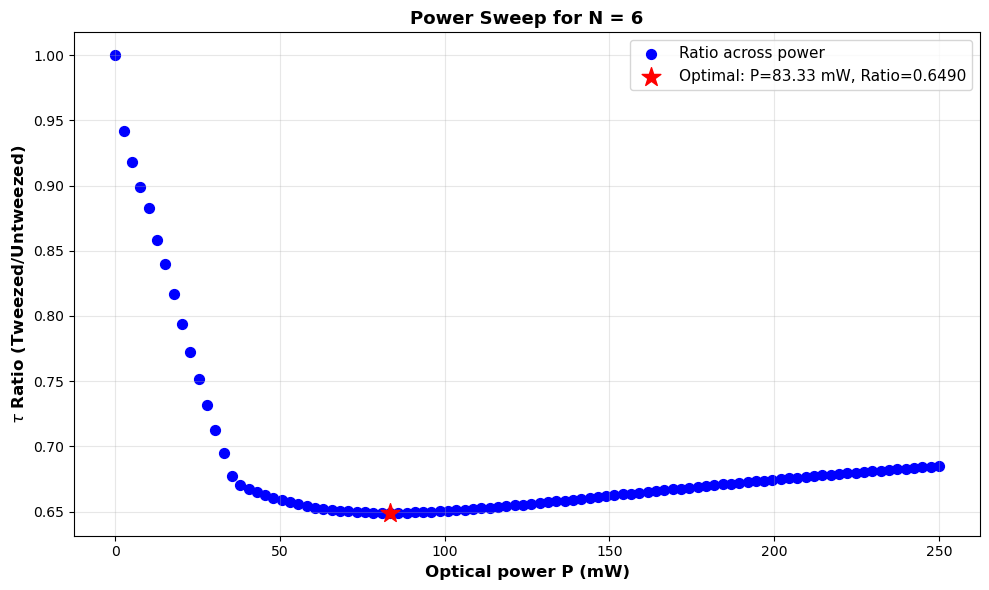


Optimal Power for N = 6:
P_opt = 8.333400e-02 W = 83.3340 mW
Ratio = 0.6490


In [233]:
# Plot power sweep for N=6 using already generated data

N = 6
idx = N - 2  # Index for N=6 in the arrays

x_tweezed = []
y_tweezed = []

# Extract scores from power_results for N=6
for P_val, winners in zip(P_list, power_results[idx]):
    if not winners:
        continue
    winner = winners[0]
    
    if len(winner) >= 3:
        tweezed_ion = winner[0]
        score = winner[2]
    else:
        continue
    
    if tweezed_ion is None:
        continue
    
    x_tweezed.append(P_val)
    y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

untweezed_ref = untweezed_winners[idx]

# Calculate ratio
ratio = untweezed_ref / y_tweezed
opt_idx = np.argmin(ratio)

opt_power_W = x_tweezed[opt_idx]
opt_power_mW = opt_power_W * 1e3
opt_ratio = ratio[opt_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50, label='Ratio across power')
ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*', 
           zorder=5, label=f'Optimal: P={opt_power_mW:.2f} mW, Ratio={opt_ratio:.4f}')
ax.set_xlabel("Optical power P (mW)", fontsize=12, fontweight='bold')
ax.set_ylabel(r"$\tau$ Ratio (Tweezed/Untweezed)", fontsize=12, fontweight='bold')
ax.set_title(f"Power Sweep for N = {N}", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nOptimal Power for N = {N}:")
print("=" * 60)
print(f"P_opt = {opt_power_W:.6e} W = {opt_power_mW:.4f} mW")
print(f"Ratio = {opt_ratio:.4f}")
print("=" * 60)